In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, learning_curve, train_test_split


In [65]:
df = pd.read_csv('almaty_psc_hospital_wrangled.csv')
df.head()

,id,name,category,city,district,latitude,longitude,rating,review_count,work_hours,address,tags,office_id,review_text,review_rating,work_day_count,work_time_count_per_day
0,9429940001088063,Специализированный центр обслуживания населени...,ЦОН,Алматы,улица Ак-Кайнар,43.308773,76.838086,3.6,2880,"{'Fri': {'working_hours': [{'from': '09:00', '...","улица Ак-Кайнар, 1",ЦОН,9429940001088063,бардак номер қателесіп беріп жіберген өзің бар...,1.0,5,9
1,9429940001088063,Специализированный центр обслуживания населени...,ЦОН,Алматы,улица Ак-Кайнар,43.308773,76.838086,3.6,2880,"{'Fri': {'working_hours': [{'from': '09:00', '...","улица Ак-Кайнар, 1",ЦОН,9429940001088063,здраствуйте хочу рассказать о случае в котором...,1.0,5,9
2,9429940001088063,Специализированный центр обслуживания населени...,ЦОН,Алматы,улица Ак-Кайнар,43.308773,76.838086,3.6,2880,"{'Fri': {'working_hours': [{'from': '09:00', '...","улица Ак-Кайнар, 1",ЦОН,9429940001088063,нервные сотрудники часов ожиданий в пустую не...,1.0,5,9
3,9429940001088063,Специализированный центр обслуживания населени...,ЦОН,Алматы,улица Ак-Кайнар,43.308773,76.838086,3.6,2880,"{'Fri': {'working_hours': [{'from': '09:00', '...","улица Ак-Кайнар, 1",ЦОН,9429940001088063,здрово,4.0,5,9
4,9429940001088063,Специализированный центр обслуживания населени...,ЦОН,Алматы,улица Ак-Кайнар,43.308773,76.838086,3.6,2880,"{'Fri': {'working_hours': [{'from': '09:00', '...","улица Ак-Кайнар, 1",ЦОН,9429940001088063,барлығы өз ісінің маманы,5.0,5,9


In [66]:
df['review_rating'] = df['review_rating'].astype(int)
df['review_rating'] = df['review_rating'].map({1: '1', 2: '2', 3: '3', 4: '4', 5: '5'})

In [67]:
df['review_rating'].value_counts()

review_rating
5    10553
1    10244
4      937
3      936
2      795
Name: count, dtype: int64

In [68]:
le_category = LabelEncoder()
df['category'] = le_category.fit_transform(df['category'])

In [69]:
df['tags'] = df['tags'].apply(lambda x: x if isinstance(x, str) else '')


In [ ]:
def convert_work_hours(work_hours_str):
    try:
        work_hours_data = eval(work_hours_str)  
        total_hours = 0
        for day, data in work_hours_data.items():
            for period in data['working_hours']:
                start_time = period['from']
                end_time = period['to']
                start_hour = int(start_time.split(':')[0])
                end_hour = int(end_time.split(':')[0])
                total_hours += (end_hour - start_hour)
        return total_hours
    except:
        return 0

df['work_time_count_per_week'] = df['work_hours'].apply(convert_work_hours)

In [71]:
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X_text = tfidf.fit_transform(df['review_text']).toarray()

In [72]:
X = np.hstack([df[['review_count', 'work_day_count', 'work_time_count_per_day', 'work_time_count_per_week', 'category']].values, X_text])
y = df['review_rating']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
model_rf = RandomForestClassifier(random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [75]:
y_pred = model_rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(f'Optimized Classification Report:\n{classification_report(y_test, y_pred)}')

Accuracy: 0.8011932665672278
Optimized Classification Report:
              precision    recall  f1-score   support

           1       0.77      0.91      0.83      2049
           2       0.14      0.01      0.01       153
           3       0.25      0.02      0.03       189
           4       0.30      0.02      0.03       184
           5       0.85      0.89      0.87      2118

    accuracy                           0.80      4693
   macro avg       0.46      0.37      0.35      4693
weighted avg       0.74      0.80      0.76      4693



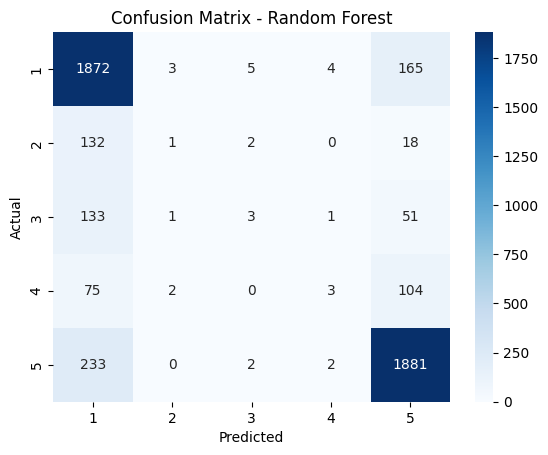

In [76]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model_rf.classes_, yticklabels=model_rf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [78]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

In [79]:
model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           1       0.76      0.89      0.82      2049
           2       0.04      0.01      0.01       153
           3       0.05      0.03      0.03       189
           4       0.09      0.04      0.05       184
           5       0.86      0.86      0.86      2118

    accuracy                           0.78      4693
   macro avg       0.36      0.36      0.36      4693
weighted avg       0.73      0.78      0.75      4693



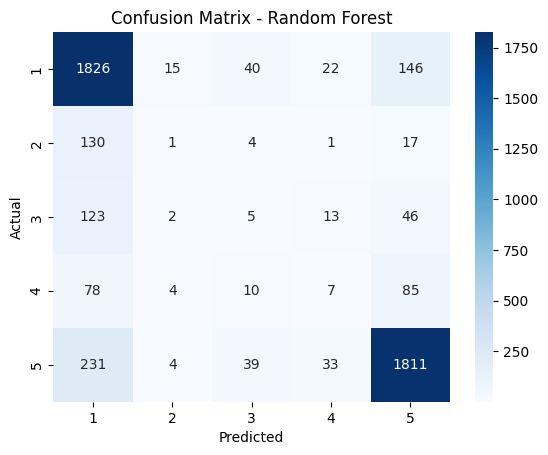

In [80]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model_rf.classes_, yticklabels=model_rf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [ ]:
undersample = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = undersample.fit_resample(X_train, y_train)

model = RandomForestClassifier(random_state=42)
model.fit(X_train_res, y_train_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [84]:
y_pred = model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           1       0.82      0.53      0.64      2049
           2       0.06      0.26      0.09       153
           3       0.07      0.20      0.11       189
           4       0.10      0.28      0.15       184
           5       0.90      0.70      0.79      2118

    accuracy                           0.57      4693
   macro avg       0.39      0.39      0.36      4693
weighted avg       0.78      0.57      0.65      4693



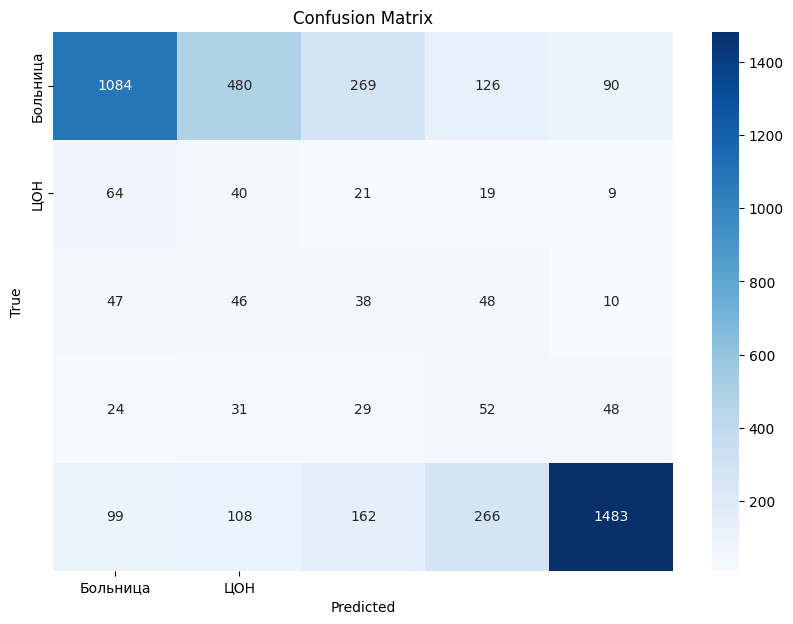

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_category.classes_, yticklabels=le_category.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
X = np.hstack([df[['review_count', 'work_day_count', 'work_time_count_per_day', 'work_time_count_per_week', 'category']].values, X_text])

y = df['review_rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

undersample = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = undersample.fit_resample(X_train, y_train)

param_dist = {
    'n_estimators': [100, 200, 500, 1000],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2', None]
}

model_rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=model_rf,
    param_distributions=param_dist,
    n_iter=100,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1_weighted'  
)

random_search.fit(X_train_res, y_train_res)

print(f"Best parameters from RandomizedSearchCV: {random_search.best_params_}")

y_pred = random_search.predict(X_test)


Fitting 3 folds for each of 100 candidates, totalling 300 fits


C:\Users\Бирганым\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
72 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Бирганым\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Бирганым\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "C:\Users\Бирганым\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 471, in _validate_param

Best parameters from RandomizedSearchCV: {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
F1-Score: 0.6738439962188435
AUC-ROC: 0.8890070983389193
Classification Report:
              precision    recall  f1-score   support

         1.0       0.85      0.56      0.67      2049
         2.0       0.05      0.21      0.09       153
         3.0       0.09      0.24      0.13       189
         4.0       0.10      0.30      0.15       184
         5.0       0.91      0.73      0.81      2118

    accuracy                           0.60      4693
   macro avg       0.40      0.41      0.37      4693
weighted avg       0.79      0.60      0.67      4693



In [97]:
print(f"F1-Score: {f1_score(y_test, y_pred, average='weighted')}")
print(f"AUC-ROC: {roc_auc_score(y_test, random_search.predict_proba(X_test), multi_class='ovr', average='weighted')}")

print("Classification Report:")
print(classification_report(y_test, y_pred))

F1-Score: 0.6738439962188435
AUC-ROC: 0.8890070983389193
Classification Report:
              precision    recall  f1-score   support

         1.0       0.85      0.56      0.67      2049
         2.0       0.05      0.21      0.09       153
         3.0       0.09      0.24      0.13       189
         4.0       0.10      0.30      0.15       184
         5.0       0.91      0.73      0.81      2118

    accuracy                           0.60      4693
   macro avg       0.40      0.41      0.37      4693
weighted avg       0.79      0.60      0.67      4693



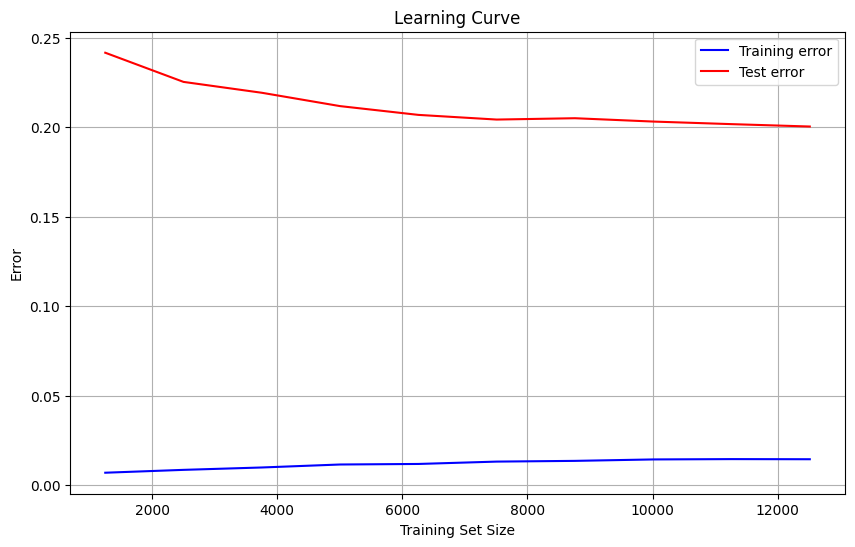

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train, cv=3, scoring='accuracy', 
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_scores_mean = 1 - train_scores.mean(axis=1)  
test_scores_mean = 1 - test_scores.mean(axis=1)  

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training error', color='blue')
plt.plot(train_sizes, test_scores_mean, label='Test error', color='red')
plt.xlabel('Training Set Size')
plt.ylabel('Error')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
cross_val_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

print(f'Cross-validation scores: {cross_val_scores}')
print(f'Mean cross-validation score: {cross_val_scores.mean()}')

Cross-validation scores: [0.80213049 0.80479361 0.80953649 0.79595099 0.80420884]
Mean cross-validation score: 0.8033240850239105
